In [57]:
import numpy as np
import pandas as pd
from google.colab import drive
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt
from math import factorial
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
data1 = pd.read_csv('/content/drive/My Drive/index_1.csv', index_col='date')
data2 = pd.read_csv('/content/drive/My Drive/index_2.csv',index_col='date')
data = pd.concat([data1, data2], ignore_index=True)

In [59]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3636 entries, 2024-03-01 to 2025-03-23
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     3636 non-null   object 
 1   cash_type    3636 non-null   object 
 2   card         3547 non-null   object 
 3   money        3636 non-null   float64
 4   coffee_name  3636 non-null   object 
dtypes: float64(1), object(4)
memory usage: 170.4+ KB


In [60]:
data.columns

Index(['datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='object')

In [61]:
print(data['coffee_name'].unique())

['Latte' 'Hot Chocolate' 'Americano' 'Americano with Milk' 'Cocoa'
 'Cortado' 'Espresso' 'Cappuccino' 'Tea' 'Chocolate with coffee'
 'Chocolate with milk' 'Coffee with Irish whiskey'
 'Irish whiskey with milk' 'Double Irish whiskey' 'Double espresso'
 'Americano with milk' 'Double espresso with milk'
 'Caramel with Irish whiskey' 'Super chocolate' 'Double vanilla'
 'Mochaccino' 'Caramel with chocolate' 'Irish whiskey' 'Caramel coffee'
 'Vanilla with Irish whiskey' 'Chocolate' 'Caramel with milk'
 'Coffee with chocolate' 'Irish with chocolate' 'Vanilla coffee'
 'Double ristretto' 'Hot milkshake' 'Double chocolate' 'Caramel']


In [62]:
data['cash_type'].unique()

array(['card', 'cash'], dtype=object)

In [63]:
def sales(data,menu):
  months=['01','02','03','04','5','6','7','8','9','10','11','12']
  sales = []
  filter_data = data[data['coffee_name']==menu]['money']
  for month in months:
    filtered = filter_data.loc[f'2024-{month}-01':f'2024-{month}-31']
    sales.append(np.round(filtered.sum()))
  return sales


In [91]:
x = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
con = np.array([1,1,1,1,1,1,1,1,1,1,1,1])
b = np.array(sales(data1,'Americano with Milk'))
a = np.array([[con],[x]])
at = np.matrix_transpose(a)
ata = at@a
print(np.linalg.inv(ata))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 2)

Polynomial coefficients (from lowest to highest degree): 
[ 7.31919893e-03 -5.21849923e-01  1.64409281e+01 -3.01294428e+02
  3.55649959e+03 -2.82721147e+04  1.53611880e+05 -5.66545845e+05
  1.37790205e+06 -2.08166872e+06  1.73432662e+06 -5.92625000e+05]


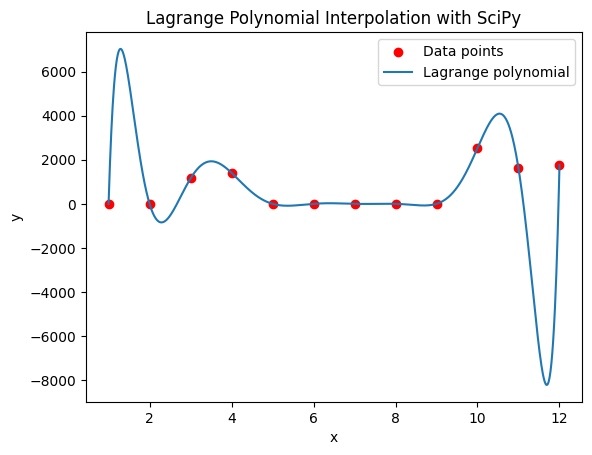

In [74]:
x = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
y = np.array(sales(data1,'Americano with Milk'))
poly = lagrange(x, y)

from numpy.polynomial.polynomial import Polynomial
# Displaying the coefficients in the standard a_n*x^n + ... a_0 order
print(f"Polynomial coefficients (from lowest to highest degree): \n{Polynomial(poly).coef}")

# 4. Evaluate the polynomial at new points
x_new = np.linspace(min(x), max(x), 1000)
y_new = poly(x_new)

# 5. Plot the results
plt.scatter(x, y, color='red', label='Data points')
plt.plot(x_new, y_new, label='Lagrange polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Lagrange Polynomial Interpolation with SciPy')
plt.show()

In [75]:
x_extrap = 13
y_extrap = poly(x_extrap)
print(f"Extrapolated value at x={x_extrap}: {np.round(y_extrap,0)}")

Extrapolated value at x=13: 705594.0


In [76]:
data1[data1['coffee_name']=='Americano'].loc['2025-01-01':'2025-01-31'].sum()

,0
datetime,2025-01-02 16:22:32.3872025-01-03 22:18:20.359...
cash_type,cardcardcardcardcardcardcardcardcardcardcardca...
card,ANON-0000-0000-1069ANON-0000-0000-1071ANON-000...
money,649.0
coffee_name,AmericanoAmericanoAmericanoAmericanoAmericanoA...


In [67]:
data.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

,money
coffee_name,
Latte,28658.30
Americano with Milk,25269.12
Cappuccino,18514.14
Americano,15437.26
Hot Chocolate,10172.46
Cocoa,8678.16
Cortado,7534.86
Espresso,3187.28
Americano with milk,1100.00
